# Substrate Integrated Waveguide Filter with CSRRs
<center><img src="misc/siw_csrr_stackup_3d.png" width=720 /></center>
An SIW is a rectangular waveguide built inside a PCB: two rows of plated through-vias
replace the side walls, so the whole structure comes out of a standard etch-and-drill
process. Etching a complementary split-ring resonator (CSRR) into the broadwall places
a sharp transmission zero just above the SIW TE₁₀ cutoff; cascading CSRRs of slightly
different sizes spreads those zeros and shapes a compact band-pass response. This notebook
reproduces the three-cell filter of Zhang, Yu & Xu [1].


## Coordinate convention

| Axis | Role        | Description                                              |
| ---- | ----------- | -------------------------------------------------------- |
| x    | propagation | along the feed lines; ports at the ±x extents            |
| y    | transverse  | across the SIW width; via rows at y = ±a/2               |
| z    | stack-up    | substrate thickness; top metal above, bottom ground below|

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.rf as rf
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tidy3d import web
from tidy3d.plugins.dispersion import FastDispersionFitter

td.config.logging.level = "ERROR"

## Parameters

Lengths in μm (tidy3d default), frequencies in Hz.

In [2]:
# Frequency sweep and field-monitor sampling
f_min = 2e9  # Hz, lower sweep edge
f_max = 12e9  # Hz, upper sweep edge (above the last CSRR zero)
n_freqs = 201  # sweep points
n_field_freqs = 201  # field-monitor frequencies

### Substrate and metal properties

The stack is RT/Duroid 5880 sandwiched between two copper layers — a low-loss microwave
laminate, so pass-band insertion loss comes from the copper conductor loss, not the
dielectric.

In [3]:
# Substrate (RT/Duroid 5880, paper Section 3)
eps_sub = 2.22  # relative permittivity
losstan_sub = 0.002  # loss tangent
h_sub = 254  # μm, substrate thickness

# Metal (copper, 1 oz PCB)
cond_metal = 58  # S/μm  (5.8e7 S/m)
t_metal = 17  # μm

### SIW, plate, and feed dimensions

<img src="misc/siw_csrr_layout_2d.png" width="920">

*Top view — SIW broadwall plate (gold) between two via rows, tapered to microstrip feeds
at each end. The three CSRR footprints sit on the SIW centreline. Feeds are intentionally
asymmetric (short on the input side, long on the output).*

In [4]:
# SIW via fence
a_siw = 14000  # μm, via-row separation (y)
via_d = 800  # μm, via diameter
via_pitch = 1600  # μm, via spacing along x

# Plate (top-metal broadwall) geometry
plate_margin_y = (
    960  # μm, plate extension past each via row in y (paper doesn't specify; ≈ 1 mm fits the photo)
)
cell_pitch_x = 6000  # μm, centre-to-centre CSRR spacing
end_margin_x = 2600  # μm, end-CSRR centre to nearest plate edge
L_plate_x = 2 * end_margin_x + 2 * cell_pitch_x  # μm = 17.2 mm
plate_half_y = a_siw / 2 + plate_margin_y  # μm = 7.96 mm

# Feed + taper
w_ms = 760  # μm, microstrip line width (50 Ω on this substrate)
L_taper = 5500  # μm, taper length (pointy tip → plate edge)
w_taper_mouth = 1720  # μm, taper mouth width at the plate edge

# Asymmetric microstrip feeds (input shorter than output).
L_ms_L = 5500  # μm, left (input) microstrip length
L_ms_R = 11500  # μm, right (output) microstrip length

### CSRR cell dimensions

<img src="misc/siw_csrr_cell.png" width="380">

*One CSRR: two concentric rectangular slot frames with a metal bridge interrupting each ring
(the "break"). Outer break on the −x arm, inner on +x — opposite sides of the propagation
axis, so the resonator's electric dipole aligns with it. `f`, `s`, `g` are shared across all
three cells; per-cell `c, d` tune where each zero lands.*

In [5]:
# CSRR geometry (shared across all three cells):
#   f = slot arm width (air-channel thickness of each ring)
#   s = inter-ring metal gap (metal strip between outer and inner slots)
#   g = break width (metal bridge in each ring; same value for both)
# Per-cell c, d tune each transmission zero.
csrr_f = 300  # μm, slot arm width
csrr_s = 200  # μm, inter-ring metal gap
csrr_g = 400  # μm, break width (outer and inner)

# Per-cell outer-ring dimensions (paper's CSRR2, CSRR1, CSRR3 = left, mid, right)
csrr_c_left = 3700  # μm, outer height (along y)
csrr_d_left = 1850  # μm, outer width  (along x)
csrr_c_mid = 4000
csrr_d_mid = 2000
csrr_c_right = 3800
csrr_d_right = 1900

In [6]:
# ==========================================
# Constants (simulation-box housekeeping)
# ==========================================
lp_impedance = 50  # Ω

# ==========================================
# Derived
# ==========================================
f0 = f_max
freqs = np.linspace(f_min, f_max, n_freqs)
field_freqs = np.linspace(f_min, f_max, n_field_freqs)

# Top-metal x-coordinates (plate centred on x=0; feeds are asymmetric).
x_plate_L = -L_plate_x / 2
x_plate_R = +L_plate_x / 2
x_taper_tip_L = x_plate_L - L_taper
x_taper_tip_R = x_plate_R + L_taper
x_ms_L = x_taper_tip_L - L_ms_L
x_ms_R = x_taper_tip_R + L_ms_R

# Finite PCB footprint — substrate + ground match the top-metal extent in y.
sub_x_center = (x_ms_L + x_ms_R) / 2
sub_x_len = x_ms_R - x_ms_L
sub_y_len = 2 * plate_half_y

# Air padding between the PCB and the PML: λ_air/4 at f_center.
air_pad = td.C_0 / f0 / 4

## Media

The substrate uses `constant_loss_tangent_model` — a dispersive fit that keeps tan δ flat
across the sweep while staying Kramers–Kronig consistent (a pure flat-loss term on its own
is non-causal and the solver rejects it). Copper uses `LossyMetalMedium`; conductor loss
sets the pass-band insertion-loss floor.

In [7]:
med_sub = FastDispersionFitter.constant_loss_tangent_model(
    eps_sub, losstan_sub, (f_min, f_max), tolerance_rms=3e-4
)
med_metal = rf.LossyMetalMedium(
    conductivity=cond_metal, frequency_range=(f_min, f_max), name="Lossy Copper"
)
med_air = td.Medium(permittivity=1.0, name="Air")

Output()

## Geometry

### Substrate and bottom ground

Substrate and bottom ground clip to the top-metal footprint — a finite PCB floating in air.
PML on all six faces then absorbs into air cleanly; an infinite-substrate setup would put
PML inside the dielectric, which it handles less reliably (residual reflection shows up
as ripple on S11). Stack-up along z: substrate `[-h, 0]`, top metal `[0, t]`, bottom
ground `[-(h+t), -h]`.

In [8]:
str_sub = td.Structure(
    geometry=td.Box(
        center=(sub_x_center, 0, -h_sub / 2),
        size=(sub_x_len, sub_y_len, h_sub),
    ),
    medium=med_sub,
)

str_gnd = td.Structure(
    geometry=td.Box(
        center=(sub_x_center, 0, -h_sub - t_metal / 2),
        size=(sub_x_len, sub_y_len, t_metal),
    ),
    medium=med_metal,
)

### CSRR slot structures

`td.Box` strips of air, layered over each slot frame, etch the CSRRs out of the top plate.
The strips must come **after** the plate in `structures` — tidy3d's later-wins ordering is
what lets the air override clear the metal inside each slot.

In [9]:
def csrr_slot_boxes(x_c, y_c, c, d, f, s, g, z_mid):
    """Decompose the two slot frames of a CSRR into axis-aligned ``td.Box`` primitives.

    Ring geometry:
    - f: slot arm width (air-channel thickness of each ring)
    - s: inter-ring metal gap (metal strip between outer and inner slot)
    - g: break width (metal bridge in each ring; same value for both)

    Orientation in this filter:
    - Outer ring (d × c): break of y-extent ``g`` on the -x (left) arm.
    - Inner ring ((d - 2(f+s)) × (c - 2(f+s))): break of y-extent ``g`` on the +x (right) arm.

    Box z-size = t_metal so the air override acts only on the top plate.
    """
    boxes = []
    rings = [
        (d, c, -1),  # outer: break on -x
        (d - 2 * (f + s), c - 2 * (f + s), +1),  # inner: break on +x
    ]
    for W, H, break_side in rings:
        arm_len = H - 2 * f  # vertical side-arm extent (corners belong to top/bottom)
        # Top and bottom horizontal arms (full width; include corners).
        boxes.append(td.Box(center=(x_c, y_c + (H - f) / 2, z_mid), size=(W, f, t_metal)))
        boxes.append(td.Box(center=(x_c, y_c - (H - f) / 2, z_mid), size=(W, f, t_metal)))
        # Left and right vertical arms.
        for side in (-1, +1):
            x_arm = x_c + side * (W - f) / 2
            if side == break_side:
                half_len = (arm_len - g) / 2
                y_off = (arm_len + g) / 4
                boxes.append(
                    td.Box(center=(x_arm, y_c + y_off, z_mid), size=(f, half_len, t_metal))
                )
                boxes.append(
                    td.Box(center=(x_arm, y_c - y_off, z_mid), size=(f, half_len, t_metal))
                )
            else:
                boxes.append(td.Box(center=(x_arm, y_c, z_mid), size=(f, arm_len, t_metal)))
    return boxes

In [10]:
# Three CSRRs along x, centred on y=0 (the SIW midline).
# Absolute x centres: -6 mm, 0, +6 mm (plate is centred on x=0).
z_top_mid = t_metal / 2

csrr_specs = [
    # (x_centre,        y_c, c,              d,              label)
    (-cell_pitch_x, 0.0, csrr_c_left, csrr_d_left, "left (CSRR2)"),
    (0.0, 0.0, csrr_c_mid, csrr_d_mid, "mid  (CSRR1)"),
    (+cell_pitch_x, 0.0, csrr_c_right, csrr_d_right, "right (CSRR3)"),
]

# Air-medium Boxes that override the plate's metal wherever a slot should be etched.
csrr_slot_structures = [
    td.Structure(geometry=box, medium=med_air)
    for (xc, yc, c, d, _) in csrr_specs
    for box in csrr_slot_boxes(xc, yc, c, d, csrr_f, csrr_s, csrr_g, z_top_mid)
]

### Top-metal structures

Plate, two tapers, two microstrip feeds — five primitives instead of one polygon so the CSRR
air-boxes override only the plate and leave the feeds alone.

In [11]:
# SIW broadwall plate — a single Box.
str_plate = td.Structure(
    geometry=td.Box(
        center=(0, 0, t_metal / 2),
        size=(L_plate_x, 2 * plate_half_y, t_metal),
    ),
    medium=med_metal,
)

# Microstrip feed lines — one Box on each side, using the asymmetric feed lengths.
str_ms_L = td.Structure(
    geometry=td.Box(
        center=((x_ms_L + x_taper_tip_L) / 2, 0, t_metal / 2),
        size=(L_ms_L, w_ms, t_metal),
    ),
    medium=med_metal,
)
str_ms_R = td.Structure(
    geometry=td.Box(
        center=((x_ms_R + x_taper_tip_R) / 2, 0, t_metal / 2),
        size=(L_ms_R, w_ms, t_metal),
    ),
    medium=med_metal,
)

# Tapers — trapezoidal PolySlabs widening from w_ms at the tip to w_taper_mouth at the plate edge.
# Vertices in counter-clockwise order.
str_taper_L = td.Structure(
    geometry=td.PolySlab(
        vertices=[
            (x_taper_tip_L, -w_ms / 2),
            (x_plate_L, -w_taper_mouth / 2),
            (x_plate_L, +w_taper_mouth / 2),
            (x_taper_tip_L, +w_ms / 2),
        ],
        axis=2,
        slab_bounds=(0, t_metal),
    ),
    medium=med_metal,
)
str_taper_R = td.Structure(
    geometry=td.PolySlab(
        vertices=[
            (x_plate_R, -w_taper_mouth / 2),
            (x_taper_tip_R, -w_ms / 2),
            (x_taper_tip_R, +w_ms / 2),
            (x_plate_R, +w_taper_mouth / 2),
        ],
        axis=2,
        slab_bounds=(0, t_metal),
    ),
    medium=med_metal,
)

top_metal_structures = [str_plate, str_taper_L, str_taper_R, str_ms_L, str_ms_R]

### Via fence

Via rows at `y = ±a/2` short the top plate to the bottom ground and form the SIW narrow
walls. Pitch must stay below `λ_d/2` at the top of the sweep; above that the fence leaks,
the guided mode radiates between vias, and S21 acquires a frequency-dependent loss floor.
Here, 1.6 mm pitch vs. ~17 mm substrate wavelength at 12 GHz gives ~10× margin. Vias pierce
both metal layers (length `h + 2t`).

In [12]:
def create_via(x_pos, y_pos):
    return td.Structure(
        geometry=td.Cylinder(
            center=(x_pos, y_pos, -h_sub / 2),
            radius=via_d / 2,
            length=h_sub + 2 * t_metal,
            axis=2,
        ),
        medium=med_metal,
    )


# Number of vias chosen to fit the plate x-extent; end-to-plate-edge margin
# follows from the fit, not half-pitch.
n_vias = int(np.round(L_plate_x / via_pitch))
via_x = np.linspace(
    -(n_vias - 1) * via_pitch / 2,
    +(n_vias - 1) * via_pitch / 2,
    n_vias,
)
str_vias = [create_via(x, y) for x in via_x for y in (-a_siw / 2, +a_siw / 2)]

structures = [str_sub, str_gnd] + top_metal_structures + csrr_slot_structures + str_vias
print(f"{n_vias} vias per row, {len(str_vias)} total")
print(f"via pitch       = {via_pitch / 1000:.3f} mm")
print(f"outer via → edge margin = {(L_plate_x / 2 - via_x[-1]) / 1000:.3f} mm")

11 vias per row, 22 total
via pitch       = 1.600 mm
outer via → edge margin = 0.600 mm


### Grid

`LayerRefinementSpec` refines the grid around metal edges and corners, where field gradients
concentrate (edge singularity). A local step `dl = 5 µm` handles the CSRR slot geometry
(`s = 200 µm` inter-ring gap — the finest in-plane feature). Globally, 25 cells per wavelength
at `f_max` sets the bulk density. Under-refined corners show up as S-parameter ripple and Z₀
drift that don't converge with longer `run_time` — the symptom that this spec is too coarse.

In [13]:
def create_layer_refinement_spec(structure_list):
    return rf.LayerRefinementSpec.from_structures(
        structures=structure_list,
        axis=2,
        min_steps_along_axis=2,
        bounds_snapping="bounds",
        corner_refinement=td.GridRefinement(dl=5, num_cells=2),
        dl_min_from_gap_width=True,
    )


lr_top = create_layer_refinement_spec(top_metal_structures)
lr_gnd = create_layer_refinement_spec([str_gnd])

grid_spec = td.GridSpec.auto(
    min_steps_per_wvl=25,
    wavelength=td.C_0 / f0,
    layer_refinement_specs=[lr_top, lr_gnd],
)

### Boundaries

PML on all six faces. The SIW itself is self-contained, but the microstrip feeds radiate
upward and the finite ground plate radiates downward, so PML beats PEC on the ±z faces too.

In [14]:
boundary_spec = td.BoundarySpec.all_sides(boundary=td.PML())

### Monitors

One field monitor on the **mid-substrate** plane (`z = -h/2`) — the natural slice for an SIW,
since TE10 `Ez` peaks there and CSRR slot fringing fields are strongest between the plate
and ground.

In [15]:
field_mon_top = td.FieldMonitor(
    center=(0, 0, -h_sub / 2),
    size=(td.inf, td.inf, 0),
    freqs=field_freqs,
    name="field_top",
)

### Ports

Each feed microstrip carries a wave port. A 2-D mode solver runs on the port plane, finds
the quasi-TEM microstrip mode, and the 3-D solver uses that mode in two places: as the
source (clean modal launch) and as a modal absorbing boundary (reflected power of the same
mode is absorbed back into the port — non-matching modes get PEC-reflected). S-parameters
come out normalised to the mode's extracted characteristic impedance `Z₀(f)`.

**Sizing the port plane.** With `num_pml = (0, 0)` (the default), the 2-D mode solver
terminates on a hard wall at the port's outer edge — the computed mode is an eigenmode of
a box with that wall as a boundary. Pick `size` so the real microstrip mode has already
decayed to ≈ 0 by the port edge; otherwise the wall confines a different mode and
`Z₀` / `n_eff` are wrong.

- `size_y = 10·w_ms` — lateral fringing decays on the scale of `h_sub`, so this is ~30·h_sub out.
- `size_z = h + 2·t + 10·h` — covers the full stack-up plus ~5·h of air above and below.
- `target_neff = √((ε_r+1)/2) ≈ 1.27` seeds the solver near the quasi-TEM branch. Without
  it the `num_modes`-closest-to-`target_neff` selection can latch onto a substrate-slab
  mode or a box-corner spurious mode, especially on wide ports.

In [16]:
wp_size_y = 10 * w_ms
wp_size_z = h_sub + 2 * t_metal + 10 * h_sub
wp_center_z = -h_sub / 2
wp_mode_spec = rf.MicrowaveModeSpec(
    num_modes=1,
    target_neff=np.sqrt((eps_sub + 1) / 2),
    impedance_specs=rf.AutoImpedanceSpec(),
)

WP1 = rf.WavePort(
    center=(x_ms_L + w_ms, 0, wp_center_z),
    size=(0, wp_size_y, wp_size_z),
    direction="+",
    mode_spec=wp_mode_spec,
    name="WP1",
)
WP2 = rf.WavePort(
    center=(x_ms_R - w_ms, 0, wp_center_z),
    size=(0, wp_size_y, wp_size_z),
    direction="-",
    mode_spec=wp_mode_spec,
    name="WP2",
)

### Simulation and TerminalComponentModeler

`run_time` must cover the CSRR ring-down. With Q ≈ 20 at ~10 GHz the decay constant
`τ = Q/(πf) ≈ 0.6 ns`; `run_time = 10 ns` is ~15 τ. Terminate sooner and the FDTD cuts the
resonance mid-decay — transmission zeros show up as shallow, broadened dips instead of sharp
nulls, and the stop-band depth depends on `run_time` rather than physics.

In [17]:
sim_size = (
    sub_x_len + 2 * air_pad,
    sub_y_len + 2 * air_pad,
    h_sub + 2 * t_metal + 2 * air_pad,
)
sim_center = (sub_x_center, 0, -h_sub / 2)

sim = td.Simulation(
    size=sim_size,
    center=sim_center,
    medium=med_air,
    grid_spec=grid_spec,
    boundary_spec=boundary_spec,
    structures=structures,
    monitors=[field_mon_top],
    run_time=10e-9,
    plot_length_units="mm",
    shutoff=1e-6,
)

In [18]:
# structure_priority_mode="equal" disables TCM's default "conductor" priority override
# (which gives LossyMetalMedium priority 90 vs. 0 for air, wiping out the list-order
# etch of the CSRR slots). With "equal" all unset priorities become 0 and later
# structures override earlier ones as usual.
tcm = rf.TerminalComponentModeler(
    simulation=sim,
    ports=[WP1, WP2],
    freqs=freqs,
    structure_priority_mode="equal",
)

## Pre-run visualization

Text(0.5, 1.0, 'Top-plate plane (z = t/2)')

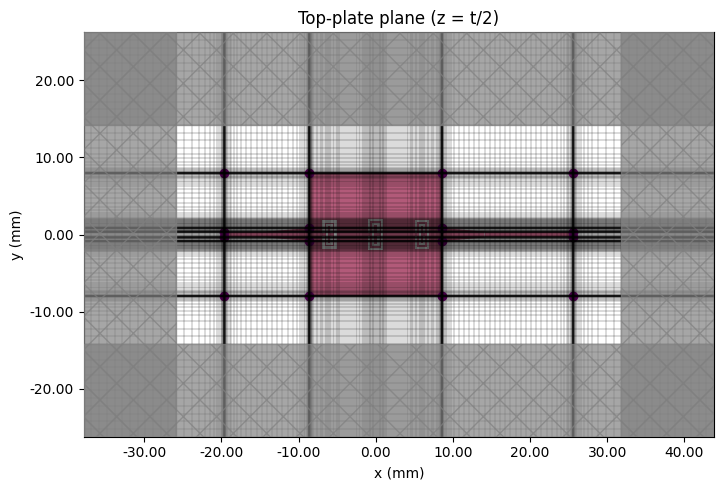

In [19]:
fig, axes = plt.subplots(figsize=(8, 5), tight_layout=True)
sim.plot(z=t_metal / 2, ax=axes)
sim.plot_grid(z=t_metal / 2, ax=axes)
axes.set_title("Top-plate plane (z = t/2)")
# axes.set_xlim(-2000, 2000)
# axes.set_ylim(-4000, +4000)

## Run simulation

In [20]:
# TCM builds per-port simulations with sources internally; validate via the TCM.
tcm.validate_pre_upload()

In [21]:
tcm_data = web.run(
    tcm,
    task_name="SIW CSRR three-cell filter",
    path="data/siw_csrr_3cell.hdf5",
    verbose=True,
    folder_name="RF examples",
)

21:59:49 PDT Created task 'SIW CSRR three-cell filter' with resource_id         
             'sid-dbd5356a-054e-4f22-8788-17fed542786c' and task_type           
             'TERMINAL_CM'.

             View task using web UI at                                          
             ]8;id=138979;https://tidy3d.simulation.cloud/rf?taskId=pa-928b20de-a683-4ba3-9729-edd82eaa75c3\'https://tidy3d.simulation.cloud/rf?]8;;\]8;id=562963;https://tidy3d.simulation.cloud/rf?taskId=pa-928b20de-a683-4ba3-9729-edd82eaa75c3\taskId]8;;\]8;id=138979;https://tidy3d.simulation.cloud/rf?taskId=pa-928b20de-a683-4ba3-9729-edd82eaa75c3\=]8;;\]8;id=275443;https://tidy3d.simulation.cloud/rf?taskId=pa-928b20de-a683-4ba3-9729-edd82eaa75c3\pa]8;;\]8;id=138979;https://tidy3d.simulation.cloud/rf?taskId=pa-928b20de-a683-4ba3-9729-edd82eaa75c3\-928b20de-a683-4ba3-97]8;;\
             ]8;id=138979;https://tidy3d.simulation.cloud/rf?taskId=pa-928b20de-a683-4ba3-9729-edd82eaa75c3\29-edd82eaa75c3']8;;\.

             Task folder: ]8;id=364235;https://tidy3d.simulation.cloud/folders/folder-f547ae6b-faf2-4c96-9096-63ca1b7bad16\'default']8;;\.

Output()

21:59:58 PDT Maximum FlexCredit cost: 7.609. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' after run.

...

22:15:33 PDT Batch status = postprocess_success

22:15:35 PDT Modeler has finished running successfully.

22:15:36 PDT Billed flex credit cost: 3.924.

Output()

22:16:21 PDT Loading results from data/siw_csrr_3cell.hdf5

In [22]:
smat = tcm_data.smatrix()

## Results

S-parameters for the three-cell filter. The SIW TE₁₀ cutoff sets the high-pass edge; the
three CSRR transmission zeros sit just above cutoff and shape the upper stop-band. The
cutoff is drawn as a vertical reference, computed from the paper's equivalent-width formula
[1, eq. 1]:

$$a_\text{eqv} = a - \frac{d^2}{0.95\, b}, \qquad f_c = \frac{c}{2\sqrt{\varepsilon_r}\, a_\text{eqv}}.$$

a_eqv    = 13.579 mm
f_cutoff = 7.41 GHz


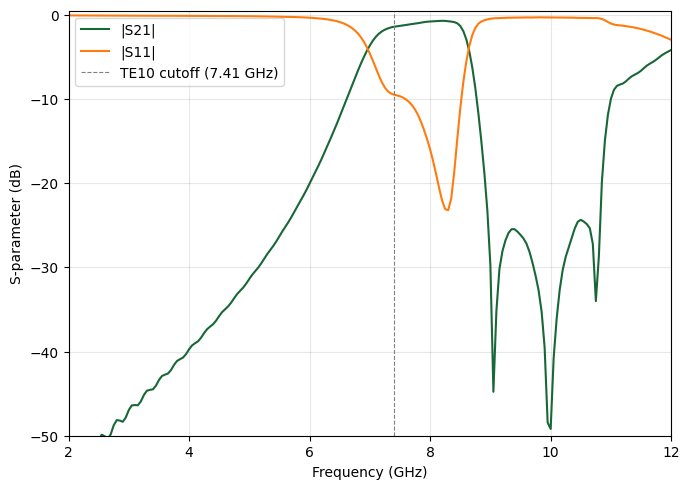

In [23]:
# TE10 cutoff from the paper's equivalent-width formula [1, eq. 1].
# a_eqv corrects the via-row separation for finite via size/pitch;
# f_cutoff is the rectangular-waveguide TE10 cutoff evaluated at a_eqv.
a_eqv = a_siw - via_d**2 / (0.95 * via_pitch)
f_cutoff = td.C_0 / (2 * np.sqrt(eps_sub) * a_eqv)
print(f"a_eqv    = {a_eqv / 1000:.3f} mm")
print(f"f_cutoff = {f_cutoff / 1e9:.2f} GHz")


def sparam(smat, i, j):
    # 1-indexed port convention; np.conjugate maps tidy3d's physics (e^{-iωt}) convention
    # to the electrical-engineering (e^{+jωt}) convention used in typical S-parameter plots.
    return np.conjugate(smat.data.isel(port_out=i - 1, port_in=j - 1))


def sparam_dB(smat, i, j):
    return 20 * np.log10(np.abs(sparam(smat, i, j)))


fig, ax = plt.subplots(figsize=(7, 5), tight_layout=True)
ax.plot(freqs / 1e9, sparam_dB(smat, 2, 1), label="|S21|")
ax.plot(freqs / 1e9, sparam_dB(smat, 1, 1), label="|S11|")
ax.axvline(
    f_cutoff / 1e9, color="gray", ls="--", lw=0.8, label=f"TE10 cutoff ({f_cutoff / 1e9:.2f} GHz)"
)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("S-parameter (dB)")
ax.set_ylim(-50, 0.5)
ax.set_xlim(f_min / 1e9, f_max / 1e9)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Field visualization

Total |E| on the mid-substrate plane at three sampling frequencies: one below the SIW
TE₁₀ cutoff (evanescent), one in the pass-band (TE₁₀ propagating), one in the upper
stop-band (CSRR trapping energy). Each panel is normalised to its own peak, which brings
out the **spatial pattern** at each frequency; for cross-frequency amplitude comparison,
normalise all three panels to a shared reference instead.

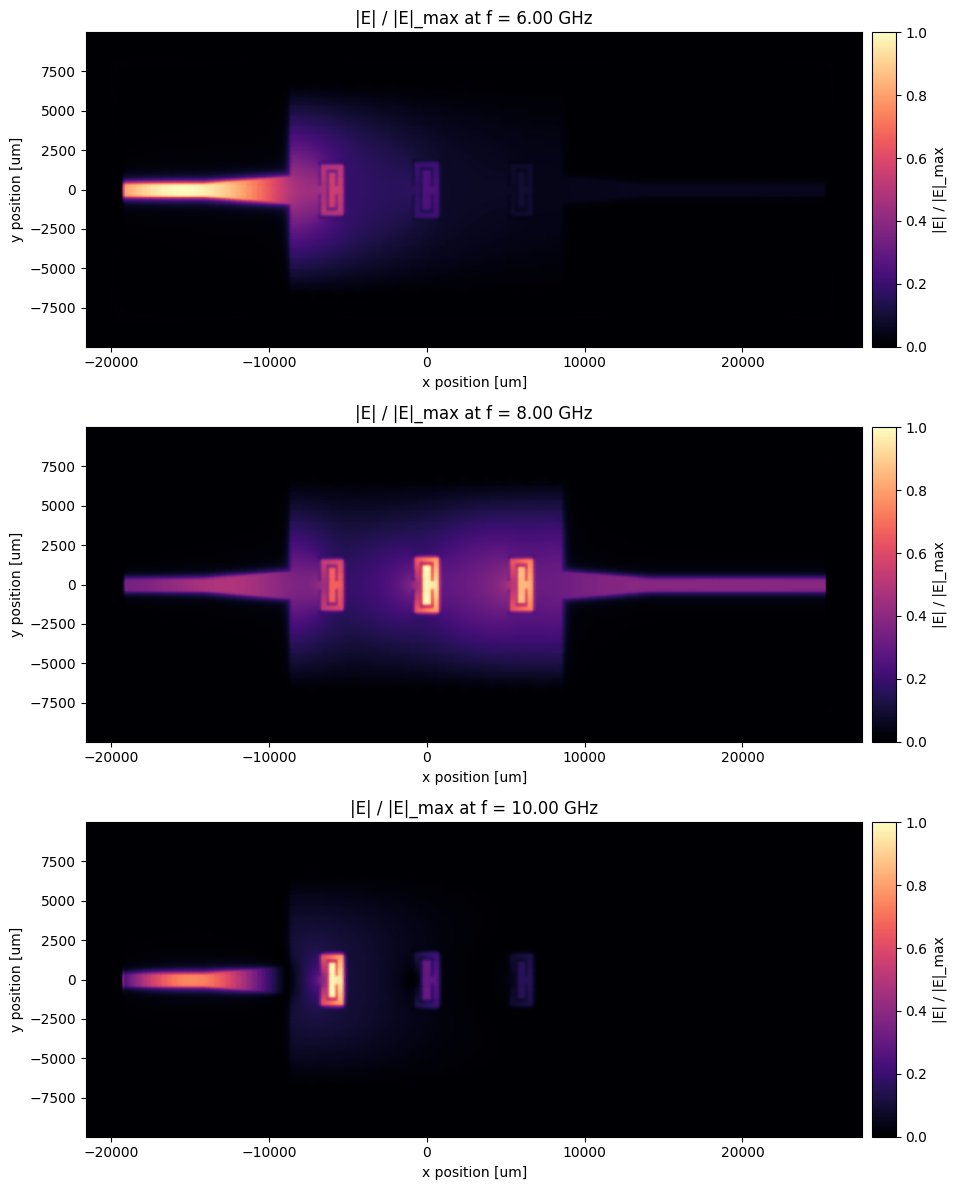

In [24]:
# Three target frequencies snapped to the nearest field-monitor samples.
freqs_plot = [6e9, 8e9, 10e9]


def snap(f):
    return field_freqs[np.argmin(np.abs(field_freqs - f))]


# Wave-port field data is indexed as "<port>@<mode index>" (multi-mode-safe key).
sim_data = tcm_data.data["WP1@0"]
fd = sim_data[field_mon_top.name]  # colocate=True by default, so Ex/Ey/Ez share one grid.

fig, axes = plt.subplots(3, 1, figsize=(12, 12), tight_layout=True)
for ax, f_target in zip(axes, freqs_plot):
    f_near = snap(f_target)
    E2 = (
        np.abs(fd.Ex.sel(f=f_near)) ** 2
        + np.abs(fd.Ey.sel(f=f_near)) ** 2
        + np.abs(fd.Ez.sel(f=f_near)) ** 2
    )
    E_abs = np.sqrt(E2).squeeze()
    E_norm = E_abs / float(E_abs.max())  # per-panel peak normalisation
    im = E_norm.plot(
        ax=ax,
        x="x",
        y="y",
        vmin=0,
        vmax=1,
        cmap="magma",
        add_colorbar=False,
        shading="gouraud",
        infer_intervals=False,
    )
    ax.set_title(f"|E| / |E|_max at f = {f_near / 1e9:.2f} GHz")
    ax.set_aspect("equal")
    # Crop to the PCB footprint; don't show the air padding around the device.
    ax.set_xlim(x_ms_L - 2000, x_ms_R + 2000)
    ax.set_ylim(-plate_half_y - 2000, plate_half_y + 2000)
    # Colorbar matched to plot height via an axes divider.
    cax = make_axes_locatable(ax).append_axes("right", size="3%", pad=0.1)
    fig.colorbar(im, cax=cax, label="|E| / |E|_max")
plt.show()

## Conclusion

Three CSRRs etched into an SIW broadwall give a compact band-pass: SIW cutoff sets the
high-pass edge, three CSRR resonances clustered just above cutoff set the low-pass edge.
Scaling `c, d` cell-to-cell widens or narrows the upper stop-band.

## References

[1] X.-C. Zhang, Z.-Y. Yu, and J. Xu, "Novel Band-pass Substrate Integrated Waveguide (SIW)
Filter Based on Complementary Split Ring Resonators (CSRRs)," *Progress In Electromagnetics
Research*, PIER 72, 39–46, 2007.